# 2026-05-22 모의투자 자동매매 60-cycle 운영 리포트

이 노트북은 `BUNDLE-20260521-POSTCLOSE` 기준으로 2026-05-22 장중에 실행한 KIS virtual paper-auto 60-cycle 운영 결과를 설명하기 위한 리포트입니다.

핵심 질문은 세 가지입니다.

1. 모의투자 자동매매 루프가 1시간 목표 구간에서 안전하게 버텼는가?
2. KIS timeout/rate limit 상황에서 fail-closed 또는 safe-skip 정책이 의도대로 동작했는가?
3. 실제 주문/체결이 있었는지, 없었다면 왜 없었는가?

주의: 이 리포트는 모의투자(`KIS_MODE=virtual`) 산출물만 사용합니다. 실계좌 주문, production registry 변경, live trading enable은 포함하지 않습니다.

## 1. 산출물 로드

아래 셀은 현재 노트북 위치와 상관없이 repo root를 찾아서 실제 JSON 리포트를 로드합니다.

사용하는 핵심 산출물:

- paper-auto 60-cycle 리포트: `artifacts/reports/paper_auto_trading/paper_auto_trade_20260522_144359.json`
- 종료 후 balance 리포트: `artifacts/reports/paper_trading/paper_trading_balance_reconciliation_20260522_144428.json`
- 모델 메타데이터: `artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/latest_model_metadata.json`

In [1]:
from __future__ import annotations

import json
from collections import Counter
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import pandas as pd

KST = ZoneInfo('Asia/Seoul')


def find_repo_root() -> Path:
    """노트북을 어느 폴더에서 실행해도 Elephant_Lab repo root를 찾는다."""
    cur = Path.cwd().resolve()
    for path in [cur, *cur.parents]:
        if (path / 'Codex-progress.md').exists() and (path / 'artifacts').exists():
            return path
    # Jupyter가 다른 cwd에서 열렸을 때를 위한 절대경로 fallback.
    fallback = Path('/Users/jangjaewon/Desktop/Elephant_Lab')
    if fallback.exists():
        return fallback
    raise FileNotFoundError('Elephant_Lab repo root를 찾지 못했습니다.')


ROOT = find_repo_root()
REPORT_PATH = ROOT / 'artifacts/reports/paper_auto_trading/paper_auto_trade_20260522_144359.json'
BALANCE_PATH = ROOT / 'artifacts/reports/paper_trading/paper_trading_balance_reconciliation_20260522_144428.json'
MODEL_META_PATH = ROOT / 'artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/latest_model_metadata.json'


def read_json(path: Path) -> dict:
    """JSON 파일을 UTF-8로 안전하게 로드한다."""
    if not path.exists():
        raise FileNotFoundError(path)
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


report = read_json(REPORT_PATH)
balance = read_json(BALANCE_PATH)
model_meta = read_json(MODEL_META_PATH)
cycles = report['stages']['cycles']['items']

print('repo_root:', ROOT)
print('paper_auto_report:', REPORT_PATH)
print('balance_report:', BALANCE_PATH)
print('cycles_loaded:', len(cycles))

repo_root: /Users/jangjaewon/Desktop/Elephant_Lab
paper_auto_report: /Users/jangjaewon/Desktop/Elephant_Lab/artifacts/reports/paper_auto_trading/paper_auto_trade_20260522_144359.json
balance_report: /Users/jangjaewon/Desktop/Elephant_Lab/artifacts/reports/paper_trading/paper_trading_balance_reconciliation_20260522_144428.json
cycles_loaded: 60


## 2. 한눈에 보는 결론

지표 해석:

- `PASS`: 해당 사이클이 실패 없이 종료된 상태입니다. 주문이 없어서 안전 스킵된 경우도 top-level cycle은 PASS일 수 있습니다.
- `SKIP`: KIS read-only 단계의 일시 오류를 주문 없이 넘긴 상태입니다. 이번 run에서는 모두 잔고 조회 timeout이 원인이었습니다.
- `fills/rejections`: 실제 broker 주문 체결/거절 개수입니다. 둘 다 0이면 이번 run은 수익률 실험이 아니라 루프 안정성 실험으로 해석해야 합니다.
- `quant_nonempty_score_cycles`: Quant가 실제 ticker score를 낸 사이클 수입니다. 0이면 모델 신호가 주문 단계까지 내려가지 않았다는 뜻입니다.

In [2]:
status_counts = Counter(c.get('status') for c in cycles)
reason_counts = Counter(
    c.get('reason') or c.get('order_guard', {}).get('reason') or 'none'
    for c in cycles
)

fills = 0
rejections = 0
execution_cycles = 0
quant_nonempty_score_cycles = 0
risk_medium_cycles = 0
future_bar_reject_cycles = 0
hot_latencies = []
portfolio_values = []

for c in cycles:
    execution = c.get('execution')
    if execution:
        execution_cycles += 1
        execution_report = execution.get('execution_report', {})
        fills += len(execution_report.get('fills') or [])
        rejections += len(execution_report.get('rejections') or [])

    hot = c.get('hot_result') or {}
    quant_output = hot.get('quant_output') or {}
    if quant_output.get('scores'):
        quant_nonempty_score_cycles += 1
    if (hot.get('risk_eval') or {}).get('severity') == 'medium':
        risk_medium_cycles += 1
    if hot.get('bar_errors'):
        future_bar_reject_cycles += 1
    if hot.get('latency_ms') is not None:
        hot_latencies.append(float(hot['latency_ms']))
    if c.get('portfolio_value') is not None:
        portfolio_values.append(float(c['portfolio_value']))

first_started = datetime.fromisoformat(cycles[0]['started_at'])
last_started = datetime.fromisoformat(cycles[-1]['started_at'])
report_saved = datetime.fromtimestamp(REPORT_PATH.stat().st_mtime, tz=KST)
wall_clock_minutes = (report_saved - first_started).total_seconds() / 60

summary = pd.DataFrame([
    ['top_level_status', report.get('status')],
    ['requested_cycles', report.get('params', {}).get('cycles')],
    ['recorded_cycles', len(cycles)],
    ['cycle_status_counts', dict(status_counts)],
    ['reason_counts', dict(reason_counts)],
    ['fills', fills],
    ['rejections', rejections],
    ['execution_cycles', execution_cycles],
    ['quant_nonempty_score_cycles', quant_nonempty_score_cycles],
    ['risk_medium_cycles', risk_medium_cycles],
    ['future_bar_reject_cycles', future_bar_reject_cycles],
    ['first_cycle_started_at', first_started.isoformat()],
    ['last_cycle_started_at', last_started.isoformat()],
    ['report_saved_at', report_saved.isoformat()],
    ['wall_clock_minutes', round(wall_clock_minutes, 2)],
    ['hot_latency_ms_avg', round(sum(hot_latencies) / len(hot_latencies), 3)],
    ['hot_latency_ms_max', round(max(hot_latencies), 3)],
], columns=['metric', 'value'])

summary

,metric,value
0,top_level_status,PASS
1,requested_cycles,60
2,recorded_cycles,60
3,cycle_status_counts,"{'PASS': 52, 'SKIP': 8}"
4,reason_counts,"{'no_order_deltas': 49, 'paper_auto_read_trans..."
5,fills,0
6,rejections,0
7,execution_cycles,0
8,quant_nonempty_score_cycles,0
9,risk_medium_cycles,9


## 3. 사이클 상태 분포

이번 run의 top-level 결과는 `PASS`입니다. 다만 모든 사이클이 broker 주문으로 이어진 것은 아닙니다.

- `PASS`: 루프가 정상 진행됐고, 대부분 `no_order_deltas`로 주문 없이 끝났습니다.
- `SKIP`: KIS 잔고 조회가 3회 timeout되어 해당 사이클을 주문 없이 넘겼습니다.

이 SKIP은 실패가 아니라 안전 정책입니다. read-only 단계에서 broker/API가 불안정하면 주문을 만들지 않고 다음 사이클로 넘어갑니다.

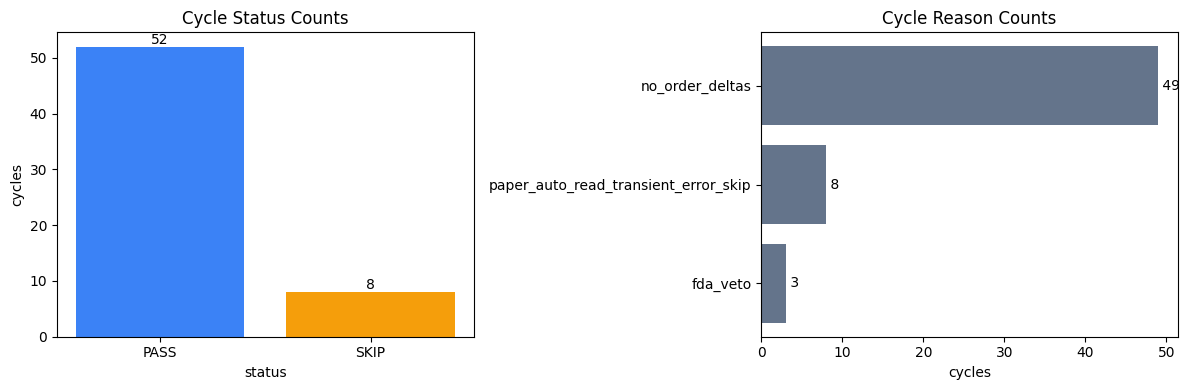

,reason,count
0,no_order_deltas,49
1,paper_auto_read_transient_error_skip,8
2,fda_veto,3


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

status_df = pd.DataFrame(status_counts.items(), columns=['status', 'count']).sort_values('status')
reason_df = pd.DataFrame(reason_counts.items(), columns=['reason', 'count']).sort_values('count', ascending=False)

axes[0].bar(status_df['status'], status_df['count'], color=['#3b82f6', '#f59e0b'][:len(status_df)])
axes[0].set_title('Cycle Status Counts')
axes[0].set_xlabel('status')
axes[0].set_ylabel('cycles')
for i, row in status_df.reset_index(drop=True).iterrows():
    axes[0].text(i, row['count'], str(row['count']), ha='center', va='bottom')

axes[1].barh(reason_df['reason'], reason_df['count'], color='#64748b')
axes[1].set_title('Cycle Reason Counts')
axes[1].set_xlabel('cycles')
axes[1].invert_yaxis()
for i, row in reason_df.reset_index(drop=True).iterrows():
    axes[1].text(row['count'], i, f" {row['count']}", va='center')

plt.tight_layout()
plt.show()

reason_df

## 4. KIS timeout safe-skip 검증

이번 run에서 가장 중요한 안정성 검증입니다.

잔고 조회가 timeout으로 3회 실패한 사이클은 `paper_auto_read_transient_error_skip`으로 기록됐습니다. 이때 `fail_closed=false`였으므로 시스템은 주문을 만들지 않고 해당 사이클만 넘겼습니다.

운영 의미:

- KIS가 순간적으로 느려져도 주문이 잘못 나가지 않습니다.
- 연속 read 오류 예산은 `max_consecutive_read_error_skips=3`입니다.
- 이번 run의 최대 연속 read skip은 2였고, 예산을 초과하지 않았습니다.

In [4]:
read_skip_rows = []
for c in cycles:
    if c.get('reason') == 'paper_auto_read_transient_error_skip':
        read_skip_rows.append({
            'cycle_index': c.get('cycle_index'),
            'status': c.get('status'),
            'consecutive_read_errors': c.get('consecutive_read_errors'),
            'max_consecutive_read_error_skips': c.get('max_consecutive_read_error_skips'),
            'fail_closed': c.get('fail_closed'),
            'exception_type': c.get('exception_type'),
        })

read_skip_df = pd.DataFrame(read_skip_rows)
read_skip_df

,cycle_index,status,consecutive_read_errors,max_consecutive_read_error_skips,fail_closed,exception_type
0,2,SKIP,1,3,False,ConnectionError
1,16,SKIP,1,3,False,ConnectionError
2,23,SKIP,1,3,False,ConnectionError
3,30,SKIP,1,3,False,ConnectionError
4,37,SKIP,1,3,False,ConnectionError
5,44,SKIP,1,3,False,ConnectionError
6,57,SKIP,1,3,False,ConnectionError
7,58,SKIP,2,3,False,ConnectionError


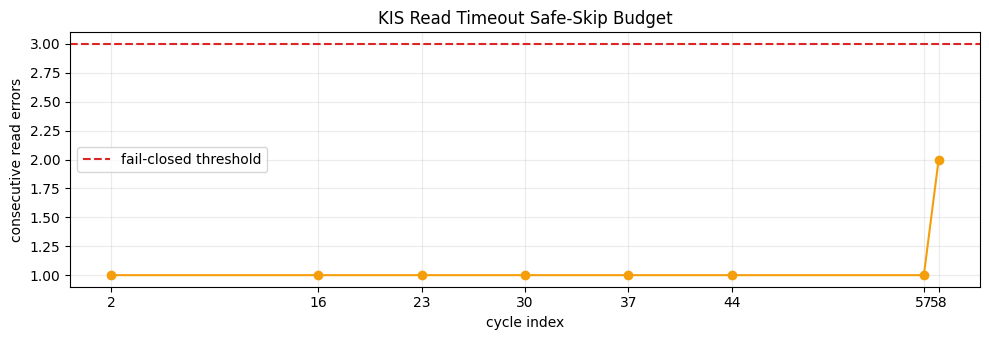

In [5]:
if not read_skip_df.empty:
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(read_skip_df['cycle_index'], read_skip_df['consecutive_read_errors'], marker='o', color='#f59e0b')
    ax.axhline(read_skip_df['max_consecutive_read_error_skips'].max(), linestyle='--', color='#dc2626', label='fail-closed threshold')
    ax.set_title('KIS Read Timeout Safe-Skip Budget')
    ax.set_xlabel('cycle index')
    ax.set_ylabel('consecutive read errors')
    ax.set_xticks(read_skip_df['cycle_index'])
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print('read timeout skip 없음')

## 5. 주문/체결/잔고 확인

이번 run은 broker 주문 실행으로 이어진 사이클이 없습니다. 따라서 이 run만 놓고 자동매매 수익률을 계산할 수는 없습니다.

수익률을 계산하려면 최소한 실제 fill이 있어야 합니다. 이번 산출물의 의미는 수익률이 아니라 다음 두 가지입니다.

1. paper-auto 루프가 KIS timeout 환경에서 죽지 않고 완주했다.
2. 실제 주문 생성 전 단계에서 Quant feature blocker가 있음을 확인했다.

In [6]:
balance_stage = balance['stages']['balance']
order_summary = pd.DataFrame([
    ['execution_cycles', execution_cycles],
    ['fills', fills],
    ['rejections', rejections],
    ['final_balance_status', balance.get('status')],
    ['cash', balance_stage['balance']['cash']],
    ['total_eval', balance_stage['balance']['total_eval']],
    ['net_asset', balance_stage['balance']['net_asset']],
    ['position_count', balance_stage['position_count']],
], columns=['metric', 'value'])

order_summary

,metric,value
0,execution_cycles,0
1,fills,0
2,rejections,0
3,final_balance_status,PASS
4,cash,479440956.0
5,total_eval,501027001.0
6,net_asset,501027001.0
7,position_count,0


## 6. Hot Path latency와 Risk Fast 경고

Hot Path latency는 모두 100ms SLA보다 훨씬 낮았습니다. 이번 run에서 평균은 약 5~6ms, 최대도 10ms 미만입니다.

Risk Fast는 일부 사이클에서 `volume_spike`를 medium risk로 감지했습니다. 하지만 주문 후보가 없었기 때문에 실제 주문 조정이나 broker execution으로 이어지지는 않았습니다.

In [7]:
cycle_rows = []
for c in cycles:
    hot = c.get('hot_result') or {}
    risk_eval = hot.get('risk_eval') or {}
    quant_output = hot.get('quant_output') or {}
    cycle_rows.append({
        'cycle_index': c.get('cycle_index'),
        'status': c.get('status'),
        'reason': c.get('reason') or c.get('order_guard', {}).get('reason') or 'none',
        'latency_ms': hot.get('latency_ms'),
        'quant_scores': len(quant_output.get('scores') or {}),
        'risk_severity': risk_eval.get('severity'),
        'triggered_rules': ','.join(risk_eval.get('triggered_rules') or []),
        'bar_error_count': len(hot.get('bar_errors') or []),
    })

cycle_df = pd.DataFrame(cycle_rows)
cycle_df.head(10)

,cycle_index,status,reason,latency_ms,quant_scores,risk_severity,triggered_rules,bar_error_count
0,0,PASS,no_order_deltas,6.286250,0,low,,0
1,1,PASS,no_order_deltas,4.078500,0,low,,0
2,2,SKIP,paper_auto_read_transient_error_skip,NaN,0,None,,0
3,3,PASS,no_order_deltas,7.163625,0,low,,6
4,4,PASS,no_order_deltas,6.255458,0,low,,0
5,5,PASS,no_order_deltas,4.229667,0,low,,0
6,6,PASS,no_order_deltas,6.577458,0,low,,10
7,7,PASS,no_order_deltas,6.730791,0,low,,0
8,8,PASS,no_order_deltas,2.510917,0,low,,0
9,9,PASS,no_order_deltas,6.835250,0,low,,6


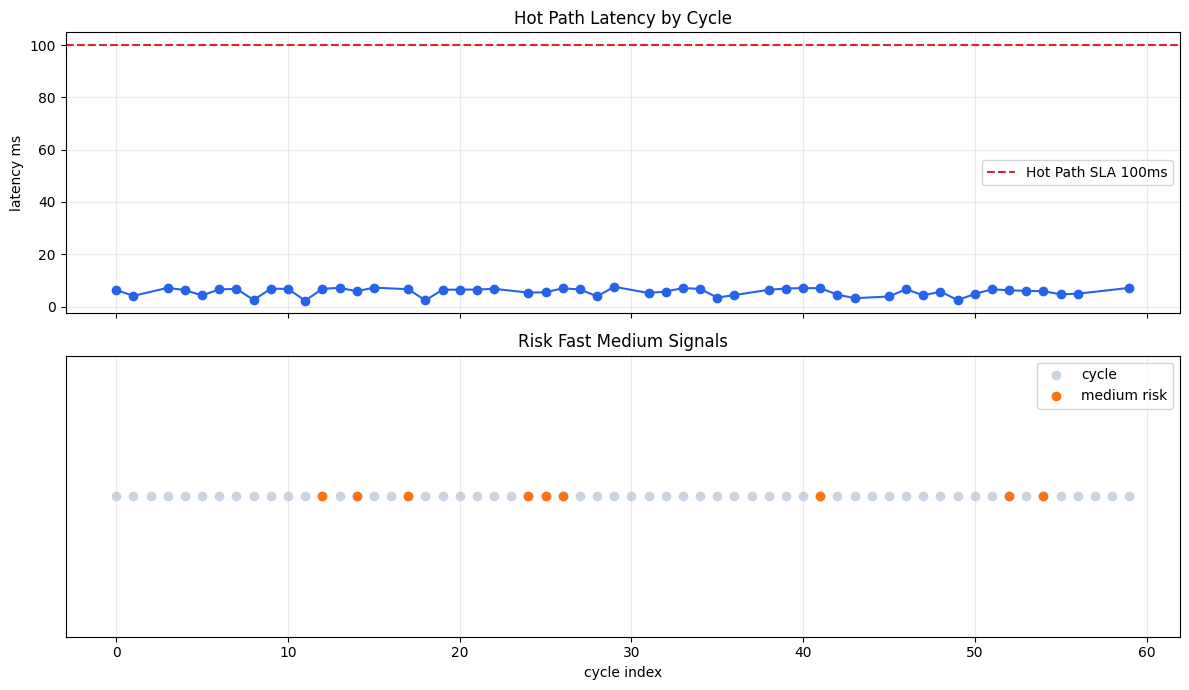

,risk_severity,triggered_rules,cycles
0,low,,43
1,medium,rule_volume_spike,9


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

latency_df = cycle_df.dropna(subset=['latency_ms'])
axes[0].plot(latency_df['cycle_index'], latency_df['latency_ms'], marker='o', linewidth=1.5, color='#2563eb')
axes[0].axhline(100, linestyle='--', color='#dc2626', label='Hot Path SLA 100ms')
axes[0].set_title('Hot Path Latency by Cycle')
axes[0].set_ylabel('latency ms')
axes[0].legend()
axes[0].grid(True, alpha=0.25)

risk_counts = cycle_df.groupby(['cycle_index', 'risk_severity']).size().reset_index(name='count')
medium_cycles = cycle_df[cycle_df['risk_severity'] == 'medium']['cycle_index']
axes[1].scatter(cycle_df['cycle_index'], [1] * len(cycle_df), color='#cbd5e1', label='cycle')
axes[1].scatter(medium_cycles, [1] * len(medium_cycles), color='#f97316', label='medium risk')
axes[1].set_title('Risk Fast Medium Signals')
axes[1].set_xlabel('cycle index')
axes[1].set_yticks([])
axes[1].legend()
axes[1].grid(True, axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

cycle_df.groupby(['risk_severity', 'triggered_rules']).size().reset_index(name='cycles')

## 7. 왜 주문이 없었나: Quant 입력 feature 진단

이번 run의 가장 중요한 blocker입니다.

산출물 기준으로 `quant_nonempty_score_cycles=0`입니다. 즉 Quant가 실제 ticker score를 한 번도 만들지 못했고, 그 결과 PPO/PM/FDA를 지나도 `order_deltas=[]`가 유지됐습니다.

운영 로그에서는 각 사이클마다 다음 경고가 반복됐습니다.

```text
[quant_agent] 005930 Dual-Source feature 누락: news_score_t. active inference skip
```

아래 셀은 모델이 `news_score_t`를 요구하는지와 당일 Dual-Source artifact가 있는지를 확인합니다.

In [9]:
feature_cols = list(model_meta.get('feature_cols') or [])
today_ds_path = ROOT / 'artifacts/dual_source/20260522.json'
yesterday_ds_path = ROOT / 'artifacts/dual_source/20260521.json'

feature_diagnosis = pd.DataFrame([
    ['bundle_id', model_meta.get('bundle_id')],
    ['model_version', model_meta.get('version')],
    ['feature_count', len(feature_cols)],
    ['requires_news_score_t', 'news_score_t' in feature_cols],
    ['today_dual_source_artifact_exists', today_ds_path.exists()],
    ['yesterday_dual_source_artifact_exists', yesterday_ds_path.exists()],
    ['quant_nonempty_score_cycles', quant_nonempty_score_cycles],
    ['no_order_deltas_cycles', reason_counts.get('no_order_deltas', 0)],
], columns=['check', 'value'])

feature_diagnosis

,check,value
0,bundle_id,BUNDLE-20260521-POSTCLOSE
1,model_version,hp-slow-conservative-lr002-l31-c80-w253-ohlcv-...
2,feature_count,14
3,requires_news_score_t,True
4,today_dual_source_artifact_exists,False
5,yesterday_dual_source_artifact_exists,True
6,quant_nonempty_score_cycles,0
7,no_order_deltas_cycles,49


## 8. 최종 해석

이번 60-cycle run의 결론은 다음과 같습니다.

- 모의투자 자동매매 루프 자체는 완주했습니다. top-level `PASS`입니다.
- KIS 잔고 조회 timeout이 여러 번 있었지만, read-only 오류는 주문 없이 `SKIP` 처리됐고 fail-closed 예산을 넘지 않았습니다.
- 실제 주문/체결/거절은 모두 0입니다. 따라서 이번 run은 수익률 검증이 아니라 운영 안정성 검증입니다.
- 실제 자동매매 신호 생성을 위해서는 `news_score_t` Dual-Source live feature 공급 경로를 먼저 고쳐야 합니다.

다음 작업 제안:

1. paper-auto preflight에서 active model이 요구하는 Dual-Source artifact가 있는지 검사합니다.
2. `PaperAutoTrader` 기본 HotRunner 생성 시 QuantAgent에 Dual-Source loader를 연결합니다.
3. 당일 artifact가 없으면 중립값으로 갈지, fail-closed로 막을지 정책을 명시합니다. 현재 로그 기준으로는 의미 없는 주문을 막는 fail-safe는 잘 작동했습니다.
4. 수정 후 5~10 cycle 짧은 paper run으로 `quant_scores > 0`과 `order_guard` 흐름을 재확인합니다.